# 01 - plot_plume_path_sum\n
Derived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [1]:
import os, platform, socket

def is_server() -> bool:
    # strong signals
    if os.getenv("JUPYTERHUB_API_URL") or os.getenv("JUPYTERHUB_USER"):
        return True
    if os.getenv("SLURM_JOB_ID"):
        return True

    # fallback heuristic (common: local macOS, server Linux)
    return platform.system() != "Darwin"

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: 22182-mbp-2.tropos.de
is_server: False


In [ ]:
from __future__ import annotations

import re, sys
from pathlib import Path
import colormaps as pcmaps
import matplotlib.axes as maxes
import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator, LogLocator, FuncFormatter

xr.set_options(keep_attrs=True)

sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))
from utilities import make_pastel, load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo

def create_new_jet3(n_colors=256, n_ice_colors=32):
    ice_colors = pcmaps.ice(np.linspace(1, 0.5, n_ice_colors))
    bk_colors  = pcmaps.BkBlAqGrYeOrReViWh200(np.linspace(0.1, 0.9, n_colors))
    transition = np.linspace(ice_colors[-1], bk_colors[0], 16)[1:-1]
    return ListedColormap(np.vstack([ice_colors, transition, bk_colors]))

new_jet4 = create_new_jet3(1024)

new_jet3 = create_new_jet3()
new_jet3_soft = make_pastel(new_jet3, desaturation=0.25, darken=0.90)


In [3]:
def format_axis_ticks(
    self,
    *,
    y_tick_pos: str = "both",
    x_tick_pos: str = "bottom",
    y_tick_labels: bool = False,
    x_tick_labels: bool = False,
    y_label: str = "",
    x_label: str = "",
    grid: bool = True,
):
    self.tick_params(which="both", direction="out", top=True, right=True, bottom=True, left=True)
    self.minorticks_on()
    self.tick_params(which="major", direction="out", length=5, width=0.9)
    self.tick_params(which="minor", direction="out", length=3, width=0.5)
    self.set_xlabel(x_label)
    self.set_ylabel(y_label)
    self.yaxis.set_ticks_position(y_tick_pos)
    self.xaxis.set_ticks_position(x_tick_pos)
    if not y_tick_labels:
        self.yaxis.set_ticklabels([])
    else:
        self.yaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))
    if not x_tick_labels:
        self.xaxis.set_ticklabels([])
    if grid:
        self.grid(True, which="major", linestyle="--", linewidth=0.25, color="black", alpha=0.6)
        self.grid(True, which="minor", linestyle=":", linewidth=0.15, color="black", alpha=0.35)
    self.set_axisbelow(False)


def format_elapsed_time(
    self,
    t0,
    t_end,
    *,
    major_interval: int = 5,
    minor_interval: int = 1,
    max_major_ticks: int = 14,
    max_minor_ticks: int = 180,
):
    """Format elapsed-time axis in minutes (numeric x axis)."""
    duration_min = float((t_end - t0) / np.timedelta64(1, "m"))
    if not np.isfinite(duration_min) or duration_min <= 0:
        return

    major_step = max(int(major_interval), int(np.ceil(duration_min / max_major_ticks)))
    minor_step = max(int(minor_interval), int(np.ceil(duration_min / max_minor_ticks)))

    major_times = np.arange(0, duration_min + major_step, major_step)
    minor_times = np.arange(0, duration_min + minor_step, minor_step)

    self.xaxis.set_major_locator(FixedLocator(major_times))
    self.xaxis.set_minor_locator(FixedLocator(minor_times))
    self.set_xticklabels([f"+{int(t):02d}" for t in major_times])


def add_missing_data_patches(
    self,
    da: xr.DataArray,
    *,
    min_consecutive: int = 2,
    add_legend: bool = True,
    y_extend=(1, 1000),
    **patch_kw,
):
    if "time" not in da.dims:
        return

    if "diameter" in da.dims:
        dvals = da["diameter"].values
        y0, y1 = dvals[0] - y_extend[0], dvals[-1] + y_extend[1]
    else:
        y0, y1 = y_extend

    collapse_dims = [d for d in da.dims if d not in {"time", "diameter"}]
    d1 = da.sum(dim=collapse_dims) if collapse_dims else da
    mask = ~(d1.sum(dim="diameter") > 0) if "diameter" in d1.dims else ~(d1 > 0)
    mask = np.asarray(mask).ravel()
    if not mask.any():
        return

    ti = np.where(mask)[0]
    split = np.where(np.diff(ti) > 1)[0] + 1
    starts = np.r_[0, split]
    ends = np.r_[split, len(ti)]
    tvals = d1["time"].values

    opts = {
        "facecolor": "lightgray",
        "edgecolor": "black",
        "alpha": 0.2,
        "linewidth": 0.2,
        "hatch": "///",
        "zorder": 1,
        **patch_kw,
    }
    for s, e in zip(starts, ends):
        if e - s < min_consecutive:
            continue
        t0, t1 = tvals[ti[s]], tvals[ti[e - 1]]
        x0, x1 = md.date2num(t0), md.date2num(t1)
        self.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, **opts))


maxes.Axes.format_axis_ticks = format_axis_ticks
maxes.Axes.format_elapsed_time = format_elapsed_time
maxes.Axes.add_missing_data_patches = add_missing_data_patches


In [5]:
def _prepare_da(ds: xr.Dataset, variable: str, *, sum_cell=True) -> xr.DataArray:
    if variable not in ds:
        raise KeyError(f"Variable '{variable}' missing. Available: {list(ds.data_vars)}")
    da = ds[variable]
    if sum_cell and "cell" in da.dims:
        da = da.sum("cell", keep_attrs=True, skipna=True)
    # if zlim is not None and "altitude" in da.coords:
    #     z0, z1 = zlim
    #     da = da.where((da.altitude >= z0) & (da.altitude <= z1), drop=True)
    return da


def _assign_elapsed_time(da: xr.DataArray, t0) -> xr.DataArray:
    mins = (da.time - t0) / np.timedelta64(1, "m")
    return da.assign_coords(time_elapsed=("time", mins.values))


def build_common_xlim(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    span_min: int = 35,
    anchor: np.datetime64 | None = None,
):
    starts = []
    for run in ds_by_run.values():
        ds = run.get(kind)
        if not isinstance(ds, xr.Dataset):
            continue
        if "time" not in ds.coords or ds.time.size == 0:
            continue
        starts.append(np.datetime64(ds.time.values.min(), "s"))

    if not starts:
        raise ValueError(f"Cannot infer xlim: no datasets with kind='{kind}' and valid time")

    if anchor is None:
        # Domain-specific default: start one minute before flare ignition.
        day = str(min(starts))[:10]
        t0 = np.datetime64(f"{day}T12:29:00")
    else:
        t0 = np.datetime64(anchor, "s")

    return [t0, t0 + np.timedelta64(int(span_min), "m")]


def _plume_path_intervals(xl):
    if xl:
        dt = np.diff(xl)[0]
        if dt < np.timedelta64(5, "m"):
            return 1, 1
        if dt < np.timedelta64(30, "m"):
            return 5, 1
        if dt < np.timedelta64(60, "m"):
            return 15, 1
        return 30, 10
    return 15, 1


def _plume_path_major_locs_from_span(span):
    if span <= 10:
        return np.array([0.1, 1, 2, 5, 10])
    if span <= 60:
        return np.array([0.1, 1, 2, 5, 10, 20, 50])
    return np.array([0.1, 1, 5, 10, 30, 60, 120])


def _plume_path_log_axis_params(xl):
    t0 = xl[0]
    x_min = float((xl[0] - t0) / np.timedelta64(1, "m"))
    x_max = float((xl[1] - t0) / np.timedelta64(1, "m"))
    if x_min <= 0:
        x_min = 0.1
    span = x_max - x_min
    major_locs = _plume_path_major_locs_from_span(span)
    return t0, x_min, x_max, span, major_locs


def compute_holimo_elapsed_anchors(
    ds_hd10,
    obs_ids,
    time_frames_plume,
    growth_times_min=None,
    seeding_start_times=None,
    var_candidates=None,
):
    if var_candidates is None:
        var_candidates = sorted([v for v in ds_hd10.data_vars if v.startswith("Ice_") and v.endswith("PSDlogNorm")])

    anchors = {}
    for i, (obs_id, (t_lo, t_hi)) in enumerate(zip(obs_ids, time_frames_plume)):
        ds_ = ds_hd10.sel(time=slice(t_lo, t_hi))
        if ds_.time.size == 0:
            anchors[obs_id] = np.nan
            continue

        # Preferred: elapsed time is referenced to mission seeding start.
        if seeding_start_times is not None and i < len(seeding_start_times):
            seed_t = np.datetime64(seeding_start_times[i])
            anchors[obs_id] = float((np.datetime64(ds_.time.values[0]) - seed_t) / np.timedelta64(1, "m"))
            continue

        # Fallback: infer anchor from first non-zero signal + growth time.
        first_idx = None
        for var in var_candidates:
            if var not in ds_.data_vars:
                continue
            arr = np.asarray(ds_[var].values)
            nz = np.isfinite(arr) & (arr > 0)
            if not nz.any():
                continue
            time_hit = int(np.argmax(nz.any(axis=tuple(range(1, arr.ndim)))))
            first_idx = time_hit if first_idx is None else min(first_idx, time_hit)

        if first_idx is None:
            anchors[obs_id] = np.nan
            continue

        dt_min = float((ds_.time[1] - ds_.time[0]).values / np.timedelta64(1, "m")) if ds_.time.size > 1 else 0.0
        growth_min = float(growth_times_min[i]) if growth_times_min is not None and i < len(growth_times_min) else 0.0
        anchors[obs_id] = growth_min + first_idx * dt_min

    return anchors


def diagnostics_table(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    variable: str = "nf",
    xlim=None,
) -> pd.DataFrame:
    rows = []
    for label, run in ds_by_run.items():
        ds = run.get(kind)
        if ds is None:
            rows.append({"run": label, "status": "missing kind"})
            continue
        if not isinstance(ds, xr.Dataset):
            rows.append({"run": label, "status": f"invalid kind type: {type(ds).__name__}"})
            continue

        row = {
            "run": label,
            "status": "ok",
            "n_cells": int(ds.sizes.get("cell", 1)),
            "n_time": int(ds.sizes.get("time", 0)),
            "time_min": str(ds.time.values.min()).split(".")[0] if "time" in ds.coords and ds.time.size else "-",
            "time_max": str(ds.time.values.max()).split(".")[0] if "time" in ds.coords and ds.time.size else "-",
            "has_var": variable in ds,
        }

        if variable in ds and "time" in ds[variable].dims and xlim is not None:
            in_win = ds[variable].sel(time=slice(xlim[0], xlim[1]))
            row["n_time_in_xlim"] = int(in_win.sizes.get("time", 0))
            row["finite_in_xlim"] = int(np.isfinite(in_win.values).sum())
        rows.append(row)

    return pd.DataFrame(rows)


def _plume_path_annotate_letters(axes):
    for i, ax in enumerate(np.atleast_1d(axes).flatten()):
        ax.text(0.02, 0.98, f'({chr(65+i)})', transform=ax.transAxes, ha='left', va='top', fontweight='semibold', fontsize=14)


def plot_plume_path_sum(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    variable: str = "nf",
    xlim=None,
    common_xlim_minutes: int | None = 35,
    ylim=(1, 2000),
    zlim=None,
    cmap="viridis",
    log_norm=True,
    x_axis_fmt: str = "elapsed",  # 'datetime', 'elapsed', 'log', 'symlog'
    add_missing_data=True,
    figsize_scale=(6.5, 3.6),
    annote_letters=True,
    holimo_overlay: dict | None = None,
    symlog_shift_start_idx: int = 0,
    symlog_panel_shift_min: float = 1.0,
):
    labels = [k for k, v in ds_by_run.items() if isinstance(v.get(kind), xr.Dataset)]
    if not labels:
        raise ValueError(f"No datasets available for kind='{kind}'")

    if x_axis_fmt in {"elapsed", "log", "symlog"} and xlim is None and common_xlim_minutes is not None:
        xlim = build_common_xlim(ds_by_run, kind=kind, span_min=common_xlim_minutes)

    n = len(labels)
    ncols = 3 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_scale[0] * ncols, figsize_scale[1] * nrows),
        constrained_layout=True,
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    pmesh = None
    panel_fill = []
    obs_legend_added = False
    xlabel = "elapsed time / (min)" if x_axis_fmt in {"elapsed", "log", "symlog"} else "time"

    obs_cfg = None
    if holimo_overlay is not None:
        obs_cfg = {
            "ds": holimo_overlay["ds_hd10"],
            "var": holimo_overlay.get("var", "Ice_PSDlogNorm"),
            "obs_ids": holimo_overlay["obs_ids"],
            "frames": holimo_overlay["time_frames_plume"],
            "growth": holimo_overlay.get("growth_times_min"),
            "seed_starts": holimo_overlay.get("seeding_start_times"),
            "threshold": holimo_overlay.get("threshold", 1.0),
            "unit_factor": holimo_overlay.get("unit_factor", 1.0),
            "scatter_cmap": holimo_overlay.get("scatter_cmap", cmap),
            "markers": holimo_overlay.get("markers", ["o", "s", "^"]),
            "sizes": holimo_overlay.get("sizes", [16, 18, 20]),
            "alpha": holimo_overlay.get("alpha", 0.9),
            "edgecolor": holimo_overlay.get("edgecolor", "black"),
            "linewidth": holimo_overlay.get("linewidth", 0.35),
            "legend_loc": holimo_overlay.get("legend_loc", "upper right"),
        }
        obs_cfg["anchors"] = holimo_overlay.get(
            "anchor_map",
            compute_holimo_elapsed_anchors(
                obs_cfg["ds"],
                obs_cfg["obs_ids"],
                obs_cfg["frames"],
                growth_times_min=obs_cfg["growth"],
                seeding_start_times=obs_cfg["seed_starts"],
            ),
        )

    for i, label in enumerate(labels):
        ax = axes[i]
        ds = ds_by_run[label].get(kind)
        if not isinstance(ds, xr.Dataset):
            ax.text(0.5, 0.5, f"Invalid data type for kind='{kind}'\n{label}", ha="center", va="center", transform=ax.transAxes)
            panel_fill.append(1.0)
            continue
        da = _prepare_da(ds, variable, sum_cell=True)

        if xlim is not None:
            da = da.sel(time=slice(xlim[0], xlim[1]))
        if da.sizes.get("time", 0) == 0:
            ax.text(0.5, 0.5, f"No data\n{label}", ha="center", va="center", transform=ax.transAxes)
            continue

        coord = "time"
        elapsed_shift = 0.0
        panel_shift = symlog_panel_shift_min if (x_axis_fmt == "symlog" and i >= symlog_shift_start_idx) else 0.0
        if x_axis_fmt in {"elapsed", "log", "symlog"}:
            t0 = xlim[0] if xlim is not None else da.time.min().values
            da = _assign_elapsed_time(da, t0)

            if x_axis_fmt == "log":
                da = da.assign_coords(time_elapsed=("time", np.where(da.time_elapsed.values <= 0, 0.1, da.time_elapsed.values)))

            if x_axis_fmt == "symlog":
                # Shift first valid plume signal to x=0.1 while preserving x=0 ignition marker.
                collapse_dims = [d for d in da.dims if d != "time"]
                valid = da.sum(dim=collapse_dims, skipna=True) > 0 if collapse_dims else da > 0
                valid_times = da.time_elapsed.where(valid, drop=True)
                if valid_times.size:
                    first_valid = float(valid_times.min().values)
                    max_shift_min = 10.0 / 60.0
                    if 0.1 < first_valid <= (0.1 + max_shift_min):
                        elapsed_shift = first_valid - 0.1
                        shifted = da.time_elapsed.values - elapsed_shift
                        da = da.assign_coords(time_elapsed=("time", np.where(shifted < 0, 0.0, shifted)))
                if panel_shift > 0:
                    da = da.assign_coords(time_elapsed=("time", np.where(da.time_elapsed.values - panel_shift < 0, 0.0, da.time_elapsed.values - panel_shift)))

            coord = "time_elapsed"

        plot_kw = {"x": coord, "y": "diameter", "ax": ax, "cmap": cmap, "add_colorbar": False}
        if zlim is not None:
            vmin, vmax = zlim
        else:
            positive = da.where(da > 0)
            vmin = float(positive.min(skipna=True))
            vmax = float(positive.max(skipna=True))

        if log_norm:
            if vmin and vmax and vmax > vmin:
                plot_kw["norm"] = LogNorm(vmin=vmin, vmax=vmax)
            else:
                plot_kw["vmin"] = vmin
                plot_kw["vmax"] = vmax

        pmesh = da.plot(**plot_kw)
        model_norm = plot_kw.get("norm", plt.Normalize(vmin=vmin, vmax=vmax))
        panel_fill.append(float(np.isfinite(da.values).sum()) / float(np.prod(da.shape)))

        if add_missing_data:
            ax.add_missing_data_patches(da, min_consecutive=1, add_legend=False)
        ax.set_title(label, fontsize=10)
        ax.set_ylim(*ylim)
        ax.set_yscale("log")
        ax.format_axis_ticks(y_tick_labels=True, x_tick_labels=True, grid=True)

        if x_axis_fmt == "elapsed":
            if xlim is not None:
                duration_min = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
                ax.set_xlim(0, duration_min)
                mi, Mi = _plume_path_intervals(xlim)
                ax.format_elapsed_time(xlim[0], xlim[1], major_interval=mi, minor_interval=Mi)
        elif x_axis_fmt == "log":
            if xlim is not None:
                t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xlim)
            else:
                t0 = da.time.values.min()
                t1 = da.time.values.max()
                t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params([t0, t1])
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)
            ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h")
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
        elif x_axis_fmt == "symlog":
            if xlim is not None:
                x_max = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
            else:
                x_max = float(np.nanmax(da.time_elapsed.values))
            x_max = max(x_max, 0.1)
            span = x_max - 0.1
            major_locs = _plume_path_major_locs_from_span(span)
            ticks = np.array([0.0] + [v for v in major_locs if v <= x_max])

            ax.set_xscale("symlog", linthresh=0.1, linscale=0.001)
            ax.set_xlim(0, x_max)
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: "0" if np.isclose(x, 0.0) else (f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h"))
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
        elif xlim is not None:
            ax.set_xlim(*xlim)

        if obs_cfg is not None and x_axis_fmt in {"elapsed", "log", "symlog"}:
            if obs_cfg["var"] not in obs_cfg["ds"].data_vars:
                continue

            for i_obs, (obs_id, (t_lo, t_hi)) in enumerate(zip(obs_cfg["obs_ids"], obs_cfg["frames"])):
                anchor = obs_cfg["anchors"].get(obs_id, np.nan)
                if not np.isfinite(anchor):
                    continue

                da_obs = obs_cfg["ds"][obs_cfg["var"]].sel(time=slice(t_lo, t_hi))
                if da_obs.time.size == 0 or "diameter" not in da_obs.dims:
                    continue

                dt_min = (da_obs.time - da_obs.time[0]).values / np.timedelta64(1, "m")
                elapsed = anchor + dt_min
                if x_axis_fmt == "log":
                    elapsed = np.where(elapsed <= 0, 0.1, elapsed)
                elif x_axis_fmt == "symlog":
                    elapsed = np.where(elapsed - elapsed_shift - panel_shift < 0, 0.0, elapsed - elapsed_shift - panel_shift)

                da_obs = da_obs.assign_coords(time_elapsed=("time", elapsed))
                da_obs = xr.where(da_obs > obs_cfg["threshold"], da_obs, np.nan) * obs_cfg["unit_factor"]
                da_obs = da_obs.transpose("time", "diameter")

                vals = np.asarray(da_obs.values, dtype=float)
                diam = np.asarray(da_obs["diameter"].values, dtype=float)
                xvals = np.asarray(da_obs.time_elapsed.values, dtype=float)
                w = np.where(np.isfinite(vals) & (vals > 0), vals, np.nan)
                denom = np.nansum(w, axis=1)
                ok = np.isfinite(denom) & (denom > 0)
                if not ok.any():
                    continue

                mean_d = np.full_like(denom, np.nan, dtype=float)
                mean_d[ok] = np.nansum(w[ok] * diam[None, :], axis=1) / denom[ok]

                # Color each dot by HOLIMO concentration at the plotted mean diameter.
                cvals = np.full_like(mean_d, np.nan, dtype=float)
                for it in np.where(ok)[0]:
                    row = vals[it]
                    finite = np.isfinite(row)
                    if finite.sum() < 2:
                        continue
                    cvals[it] = np.interp(mean_d[it], diam[finite], row[finite], left=np.nan, right=np.nan)

                mk = obs_cfg["markers"][i_obs % len(obs_cfg["markers"])]
                size = obs_cfg["sizes"][i_obs % len(obs_cfg["sizes"])]
                valid_scatter = np.isfinite(xvals) & np.isfinite(mean_d) & np.isfinite(cvals)
                if isinstance(model_norm, LogNorm):
                    valid_scatter &= cvals > 0
                if not valid_scatter.any():
                    continue
                ax.scatter(
                    xvals[valid_scatter],
                    mean_d[valid_scatter],
                    c=cvals[valid_scatter],
                    cmap=obs_cfg["scatter_cmap"],
                    norm=model_norm,
                    marker=mk,
                    s=size,
                    alpha=obs_cfg["alpha"],
                    edgecolors=obs_cfg["edgecolor"],
                    linewidths=obs_cfg["linewidth"],
                    zorder=126,
                    label=obs_id,
                )

            if not obs_legend_added and ax.collections:
                handles = []
                for j, obs_id in enumerate(obs_cfg["obs_ids"]):
                    mk = obs_cfg["markers"][j % len(obs_cfg["markers"])]
                    handles.append(
                        Line2D(
                            [0], [0],
                            marker=mk,
                            linestyle="None",
                            markerfacecolor="grey",
                            markeredgecolor="black",
                            markeredgewidth=0.4,
                            markersize=5,
                            alpha=0.8,
                            label=obs_id,
                        )
                    )
                ax.legend(handles=handles, title="HOLIMO missions", fontsize=7, title_fontsize=7, loc=obs_cfg["legend_loc"], framealpha=0.8)
                obs_legend_added = True

        # Re-apply axis mode after HOLIMO overlay (xarray plotting may reset axis state).
        if x_axis_fmt == "elapsed":
            if xlim is not None:
                duration_min = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
                ax.set_xlim(0, duration_min)
                mi, Mi = _plume_path_intervals(xlim)
                ax.format_elapsed_time(xlim[0], xlim[1], major_interval=mi, minor_interval=Mi)
            ax.set_xlabel("")
        elif x_axis_fmt == "log":
            if xlim is not None:
                _, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xlim)
            else:
                x_min = 0.1
                x_max = float(np.nanmax(da.time_elapsed.values)) if "time_elapsed" in da.coords else 1.0
                span = x_max - x_min
                major_locs = _plume_path_major_locs_from_span(span)
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)
            ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h")
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
            ax.set_xlabel("")
        elif x_axis_fmt == "symlog":
            if xlim is not None:
                x_max = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
            else:
                x_max = float(np.nanmax(da.time_elapsed.values)) if "time_elapsed" in da.coords else 1.0
            x_max = max(x_max, 0.1)
            span = x_max - 0.1
            major_locs = _plume_path_major_locs_from_span(span)
            ticks = np.array([0.0] + [v for v in major_locs if v <= x_max])
            ax.set_xscale("symlog", linthresh=0.1, linscale=0.01)
            ax.set_xlim(0, x_max)
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: "0" if np.isclose(x, 0.0) else (f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h"))
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
            ax.set_xlabel("")
        elif xlim is not None:
            ax.set_xlim(*xlim)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    if pmesh is not None:
        unit = da.attrs.get("units", "-")
        fig.colorbar(pmesh, ax=axes, extend="both", shrink=0.6, aspect=30, pad=0.005, label=rf"{kind} {variable} per bin / ({unit})")

    if annote_letters:
        _plume_path_annotate_letters(axes)

    fig.supylabel("equivalent diameter / (µm)")
    fig.supxlabel(xlabel)

    return fig, axes[:n]


In [6]:
# ---- user config ----
PROCESSED_ROOT = Path("processed")
RUNS = [
    # active in figure1
    {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    # {"label": "400m, inp 1e6, ccn 0 (run B)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},

    # previously commented in figure1 (now included)
    # {"label": "400m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
    # {"label": "400m, inp 1e6, ccn 0 (spherical)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    # {"label": "400m, inp 1e6, ccn 400 (analytic)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    # {"label": "400m, inp 1e6, ccn 400 (planar)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    # {"label": "400m, inp 1e6, ccn 400 (spherical)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    # {"label": "400m, inp 1e6, ccn 400 (columnar 2)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    # {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    # {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
    # {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]

KINDS = ("integrated",)

datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=KINDS,
)

try:
    xlim = build_common_xlim(datasets, kind="integrated", span_min=35)
except ValueError:
    # Fallback window if no valid times are discoverable in current environment.
    xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]

diag = diagnostics_table(datasets, kind="integrated", variable="nf", xlim=xlim)
print(diag.to_string(index=False))





Empty DataFrame
Columns: []
Index: []


In [7]:

if is_server():
    holimo_file      = '/work/bb1262/user/schimmel/cloudlab_data/holimo/2023-01-25/CL_20230125_1000_1140_SM058_SM060_ts1.nc'
else:
    holimo_file      = '/Users/schimmel/code/polarcap/python/plotting_scripts/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc'

time_window_holimo = (np.datetime64('2023-01-25T10:10:00'), np.datetime64('2023-01-25T12:00:00'))
time_frames_plume = [   
                    [ np.datetime64('2023-01-25T10:55:00'), np.datetime64('2023-01-25T11:10:00')   ],
                    [ np.datetime64('2023-01-25T10:35:00'), np.datetime64('2023-01-25T10:50:00')   ],
                    [ np.datetime64('2023-01-25T11:24:00'), np.datetime64('2023-01-25T11:39:00')   ],
                    ]

obs_ids = [
    "SM059", 
    "SM058", 
    "SM060"
    ]
growth_times_min = [
    6.1, 
    8.0, 
    9.1,
    ]
seeding_start_times = [
    np.datetime64('2023-01-25T10:50:00'),
    np.datetime64('2023-01-25T10:28:00'),
    np.datetime64('2023-01-25T11:15:00'),
]




ds_holimo, lbb, cbb = load_and_prepare_holimo(holimo_file)
ds_holimo = ds_holimo.sel(time=slice(*time_window_holimo))
ds_holimo = ds_holimo.assign_coords({'diameter': ds_holimo.diameter * 1e6})
ds_hd10   = ds_holimo.resample(time='10s').mean()


# Optional HOLIMO overlay: requires ds_hd10, obs_ids, time_frames_plume, growth_times_min.
holimo_ice_var = "Ice_Pristine_PSDnoNorm"
holimo_overlay_cfg = None
if all(name in globals() for name in ["ds_hd10", "obs_ids", "time_frames_plume", "growth_times_min"]):
    holimo_overlay_cfg = {
        "ds_hd10": ds_hd10,
        "obs_ids": obs_ids,
        "time_frames_plume": time_frames_plume,
        "growth_times_min": growth_times_min,
        "seeding_start_times": seeding_start_times,
        "var": holimo_ice_var,
        "threshold": 1e-10,
        "unit_factor": 1e3,
        "scatter_cmap": new_jet3,
        "markers": ["o", "s", "^"],
        "sizes": [16, 18, 20],
        "alpha": 0.9,
        "edgecolor": "black",
        "linewidth": 0.35,
        "legend_loc": "upper right",
    }

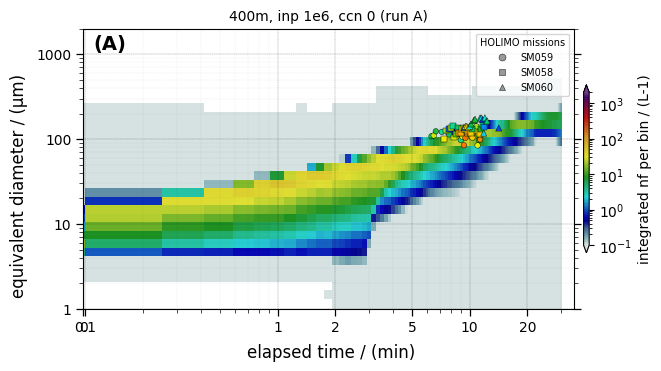

In [ ]:



x_axis_fmt = ["symlog"] #"elapsed", "log", 
for x_axis_fmt in x_axis_fmt:
    fig, axes = plot_plume_path_sum(
        datasets,
        kind="integrated",
        variable="nf",
        xlim=xlim,
        common_xlim_minutes=35,
    ylim=(1, 2e3),
    zlim=(1e-1, 2e3),
    cmap=new_jet3_soft,
    log_norm=True,
    x_axis_fmt=x_axis_fmt,
    add_missing_data=True,
    holimo_overlay=holimo_overlay_cfg,
    )
    for ax in axes:
        ax.set_ylim(1, 2e3)
    fig.savefig(f"plume_path_plot_clean_{x_axis_fmt}.png")
    